In [ ]:
"""
4. XAI

학습된 모델이 "왜 이 MRI를 악성이라고 판단했는지"를 시각적으로 설명하는 코드
"""

In [2]:
# 구글 드라이브 연동
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 패키지 & 라이브러리
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from captum.attr import IntegratedGradients
from torchvision.models.efficientnet import MBConv

In [4]:
# 한글 폰트
!apt-get install -y fonts-nanum > /dev/null 2>&1
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"디바이스: {device}")

디바이스: cpu


In [6]:
# 경로 설정
BASE_PATH  = "/content/drive/MyDrive/AI_Project/BrainScan_XAI/archive"
MODEL_PATH = "/content/drive/MyDrive/AI_Project/BrainScan_XAI/models"
TEST_PATH  = f"{BASE_PATH}/Testing"

In [7]:
# 모델 불러오기

# EfficientNet inplace 연산 패치 (XAI 호환성)
original_forward = MBConv.forward

def patched_forward(self, input):
    result = self.block(input)
    if self.use_res_connect:
        result = self.stochastic_depth(result)
        result = result + input  # += → = + 로 교체
    return result

MBConv.forward = patched_forward

# SiLU inplace 비활성화
def fix_silu(model):
    for module in model.modules():
        if isinstance(module, torch.nn.SiLU):
            module.inplace = False
    return model

model = models.efficientnet_b3(weights=None)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, 4)
)
model.load_state_dict(torch.load(f"{MODEL_PATH}/best_model.pth", map_location=device))
model = fix_silu(model)
model = model.to(device)
model.eval()
print("모델 로드 완료")

모델 로드 완료


In [8]:
# 전처리 + DataLoader

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder(TEST_PATH, transform=val_test_transform)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)
CLASSES = test_dataset.classes
print(f"클래스: {CLASSES}")

클래스: ['glioma', 'meningioma', 'notumor', 'pituitary']


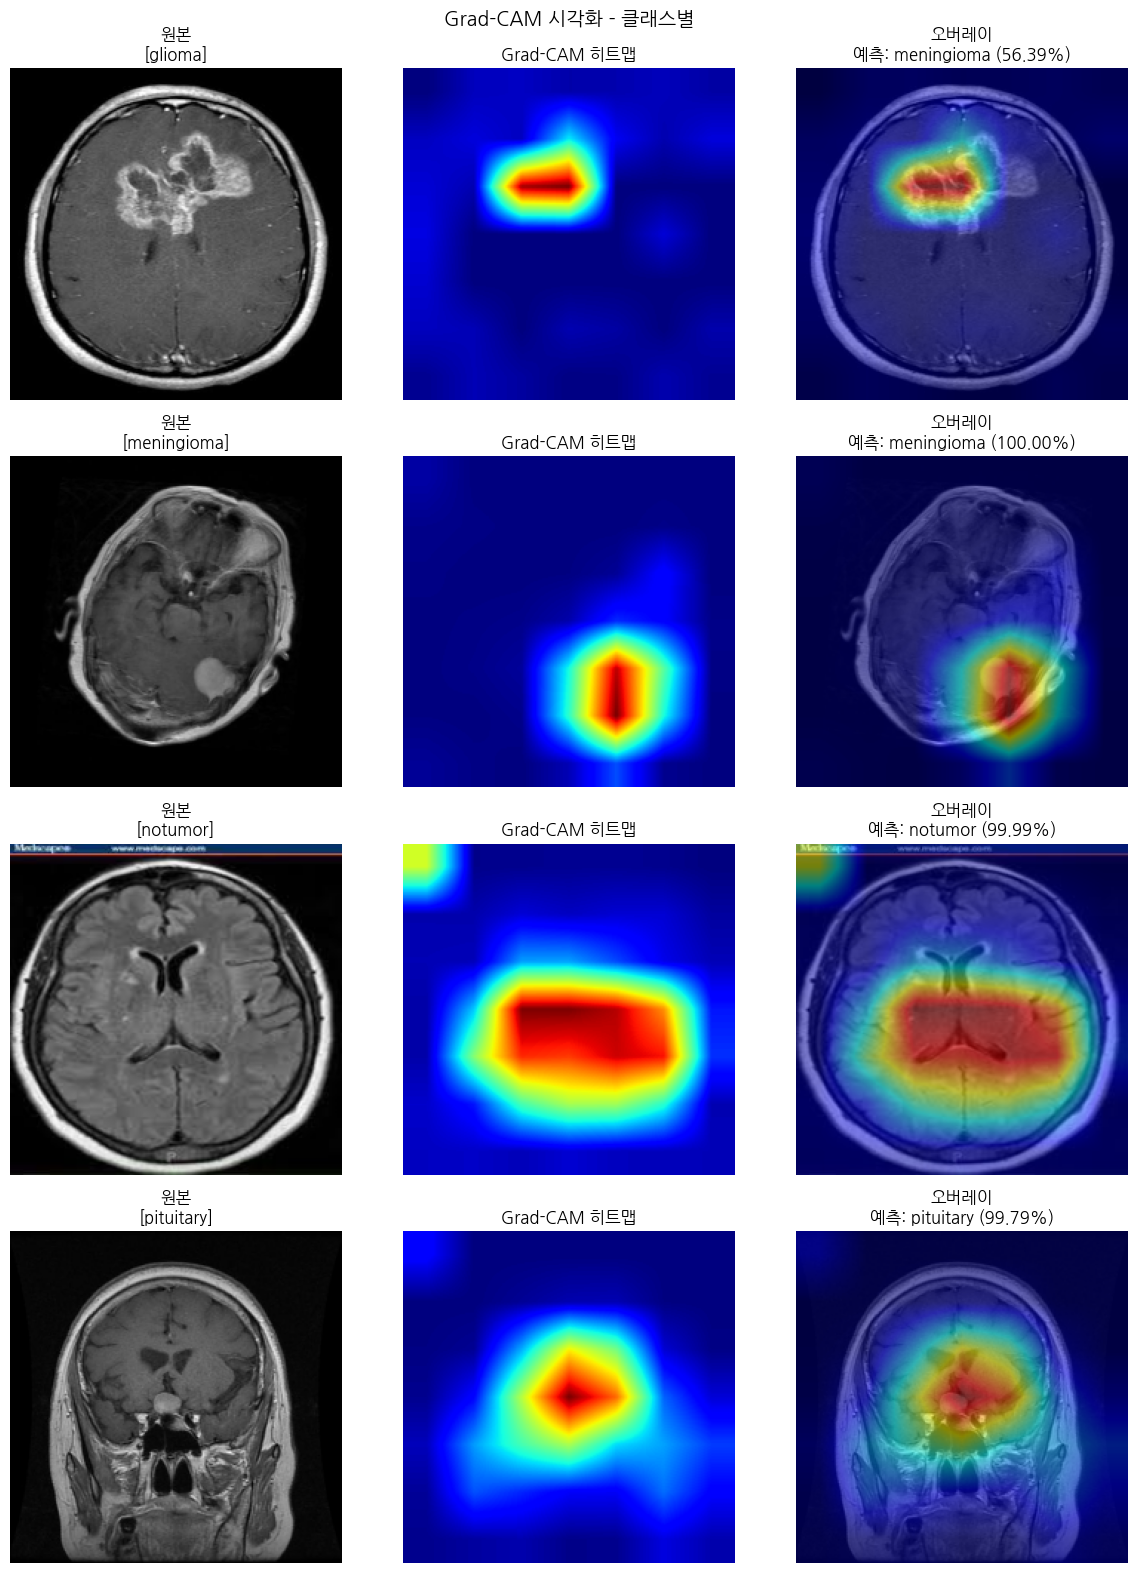

In [9]:
# Grad-CAM
# 모델이 어느 영역을 보고 판단했는지 히트맵으로 시각화
target_layers = [model.features[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, cls in enumerate(CLASSES):
    cls_idx = test_dataset.class_to_idx[cls]
    img_path = [p for p, l in test_dataset.samples if l == cls_idx][0]

    raw = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    raw_resized = cv2.resize(raw, (224, 224))
    rgb_float = raw_resized.astype(np.float32) / 255.0

    input_tensor = val_test_transform(
        __import__('PIL').Image.fromarray(raw)
    ).unsqueeze(0).to(device)

    targets = [ClassifierOutputTarget(cls_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    cam_image = show_cam_on_image(rgb_float, grayscale_cam, use_rgb=True)

    with torch.no_grad():
        output = model(input_tensor)
        pred = CLASSES[output.argmax(1).item()]
        conf = torch.softmax(output, dim=1).max().item()

    axes[row][0].imshow(raw_resized)
    axes[row][0].set_title(f"원본\n[{cls}]")
    axes[row][0].axis('off')

    axes[row][1].imshow(grayscale_cam, cmap='jet')
    axes[row][1].set_title("Grad-CAM 히트맵")
    axes[row][1].axis('off')

    axes[row][2].imshow(cam_image)
    axes[row][2].set_title(f"오버레이\n예측: {pred} ({conf:.2%})")
    axes[row][2].axis('off')

plt.suptitle("Grad-CAM 시각화 - 클래스별", fontsize=14)
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/gradcam_results.png", dpi=150)
plt.show()

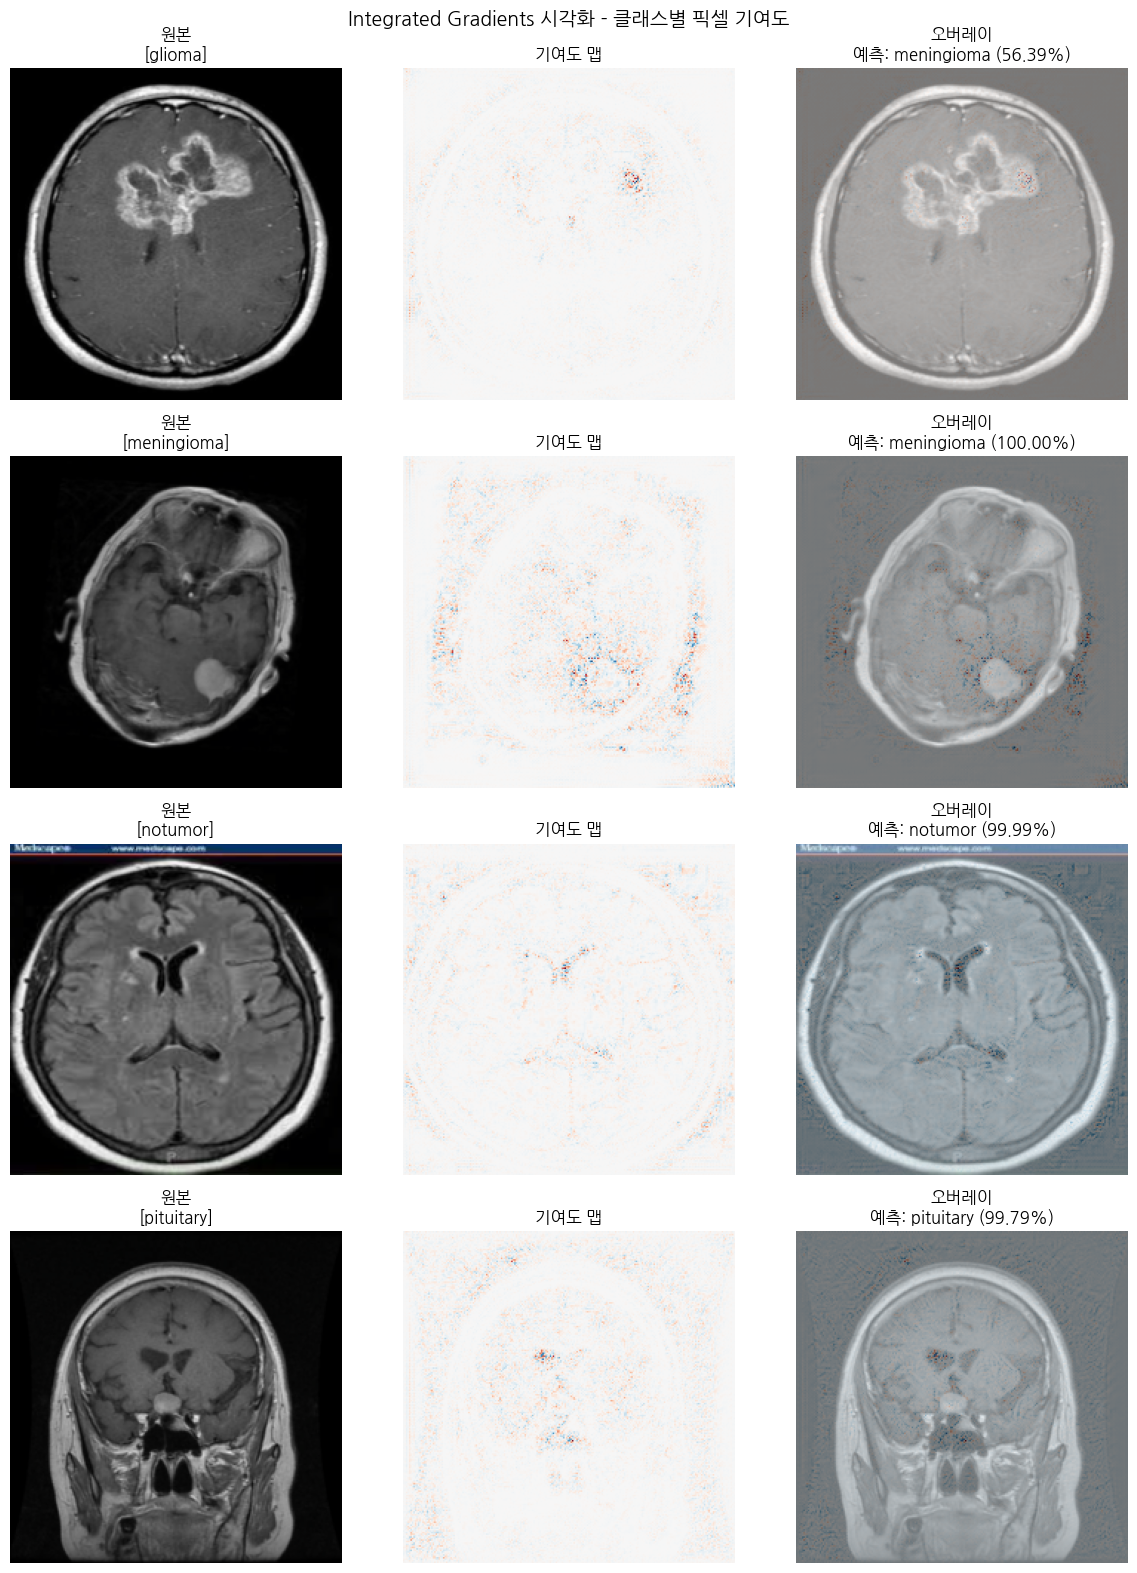

In [10]:
# Integrated Gradients
# 픽셀별 기여도 시각화 - 빨강(양수): 판단에 기여, 파랑(음수): 반대로 작용
ig = IntegratedGradients(model)

fig, axes = plt.subplots(4, 3, figsize=(12, 16))

for row, cls in enumerate(CLASSES):
    cls_idx = test_dataset.class_to_idx[cls]
    img_path = [p for p, l in test_dataset.samples if l == cls_idx][0]

    raw = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    input_tensor = val_test_transform(
        __import__('PIL').Image.fromarray(raw)
    ).unsqueeze(0).to(device)
    input_tensor.requires_grad = True

    attributions = ig.attribute(input_tensor, target=cls_idx)
    attr = attributions.squeeze().cpu().detach().numpy()
    attr = attr.transpose(1, 2, 0).mean(axis=2)

    orig = input_tensor.squeeze().cpu().detach().numpy().transpose(1, 2, 0)
    orig = orig * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    orig = np.clip(orig, 0, 1)

    with torch.no_grad():
        output = model(input_tensor)
        pred = CLASSES[output.argmax(1).item()]
        conf = torch.softmax(output, dim=1).max().item()

    axes[row][0].imshow(orig)
    axes[row][0].set_title(f"원본\n[{cls}]")
    axes[row][0].axis('off')

    axes[row][1].imshow(attr, cmap='RdBu_r',
                        vmin=-np.abs(attr).max(),
                        vmax=np.abs(attr).max())
    axes[row][1].set_title("기여도 맵")
    axes[row][1].axis('off')

    attr_norm = (attr - attr.min()) / (attr.max() - attr.min() + 1e-8)
    axes[row][2].imshow(orig)
    axes[row][2].imshow(attr_norm, cmap='RdBu_r', alpha=0.5)
    axes[row][2].set_title(f"오버레이\n예측: {pred} ({conf:.2%})")
    axes[row][2].axis('off')

plt.suptitle("Integrated Gradients 시각화 - 클래스별 픽셀 기여도", fontsize=14)
plt.tight_layout()
plt.savefig(f"{MODEL_PATH}/ig_results.png", dpi=150)
plt.show()